# MSDS 6004 — Inteligencia Artificial · Taller 3
## P1 · Aprendizaje No Supervisado — Smart Building Dataset (SBDS)
### Análisis Multivariable · Literales D, E y F

**Pares de variables analizadas (un par de cada sector):**

| Par | Variables | Descripción |
|---|---|---|
| **NE** | `V005_vent01_CO2` + `V006_vent01_temp_out` | Ventilación Norte-Este — CO2 (ppm) y Temperatura (°C) |
| **SW** | `V022_vent02_CO2` + `V023_vent02_temp_out` | Ventilación Sur-Oeste — CO2 (ppm) y Temperatura (°C) |

> El análisis univariable (literales A, B, C) se encuentra en el notebook `P1_UML_Analysis.ipynb`. Este notebook continúa con los literales D y E del taller, manteniendo el mismo estilo metodológico y de presentación.

**Patrón diario multivariable:** vector de **48 puntos** por día (24 h de CO2 + 24 h de Temperatura concatenadas). Cada día se proyecta entonces a un espacio de 48 dimensiones, normalizado por variable.

---
### Hoja de ruta
1. **Carga y construcción** de matriz `(días × 48)` para cada par de variables
2. **Literal D** — Patrones conjuntos con 3 técnicas (K-Means + Ward + GMM) + PCA + ANOVA + caracterización temporal
3. **Literal E** — Anomalías conjuntas con 3 técnicas (Mahalanobis + Isolation Forest + LOF)
4. **Literal F** — Conclusiones generales del análisis multivariable


## 0 · Configuración


In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist, mahalanobis

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                              davies_bouldin_score, calinski_harabasz_score)

PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#795548']
SAVE_PATH = 'images'
os.makedirs(SAVE_PATH, exist_ok=True)

RND = 42
np.random.seed(RND)
print('✓ Librerías cargadas correctamente.')

✓ Librerías cargadas correctamente.


## 1 · Carga y Construcción de Matrices Multivariables

Para cada par (NE y SW) construimos la **matriz de perfiles diarios conjuntos**:

$$X_{\text{par}} \in \mathbb{R}^{N \times 48}, \quad x_d = [\text{CO2}_{0\text{h}}, ..., \text{CO2}_{23\text{h}}, \text{Temp}_{0\text{h}}, ..., \text{Temp}_{23\text{h}}]$$

Se descartan días con horas faltantes y temperaturas físicamente imposibles.


In [2]:
DATA_PATH = os.path.join('..', 'data', 'data.csv')

df = pd.read_csv(DATA_PATH, sep=';')
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d.%m.%Y %H:%M')
df = df.sort_values('timestamp').reset_index(drop=True)
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

# Filtrar valores físicamente imposibles
df.loc[df['V006_vent01_temp_out'] < 5, 'V006_vent01_temp_out'] = np.nan
df.loc[df['V023_vent02_temp_out'] < 5, 'V023_vent02_temp_out'] = np.nan

print(f'Registros totales : {len(df):,}')
print(f'Rango temporal    : {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
print(f'Días únicos       : {df["date"].nunique():,}')

Registros totales : 25,942
Rango temporal    : 2012-06-23 → 2015-06-08
Días únicos       : 1,081


In [3]:
def build_pair_profile(df_raw, var_co2, var_tmp):
    """Devuelve (X[N x 48], X_co2[N x 24], X_tmp[N x 24], dates)."""
    p_co2 = df_raw.pivot_table(index='date', columns='hour', values=var_co2, aggfunc='mean')
    p_tmp = df_raw.pivot_table(index='date', columns='hour', values=var_tmp, aggfunc='mean')
    common = p_co2.dropna().index.intersection(p_tmp.dropna().index)
    p_co2, p_tmp = p_co2.loc[common], p_tmp.loc[common]
    X_co2, X_tmp = p_co2.values, p_tmp.values
    X = np.hstack([X_co2, X_tmp])  # 24 + 24 = 48
    return X, X_co2, X_tmp, pd.to_datetime(common)

# Pareja Norte-Este
X_NE, X_NE_co2, X_NE_tmp, dates_NE = build_pair_profile(
    df, 'V005_vent01_CO2', 'V006_vent01_temp_out')
# Pareja Sur-Oeste
X_SW, X_SW_co2, X_SW_tmp, dates_SW = build_pair_profile(
    df, 'V022_vent02_CO2', 'V023_vent02_temp_out')

print(f'NE (CO2+Temp): {X_NE.shape[0]} días × {X_NE.shape[1]} features (24 CO2 + 24 Temp)')
print(f'SW (CO2+Temp): {X_SW.shape[0]} días × {X_SW.shape[1]} features (24 CO2 + 24 Temp)')

NE (CO2+Temp): 1076 días × 48 features (24 CO2 + 24 Temp)
SW (CO2+Temp): 1078 días × 48 features (24 CO2 + 24 Temp)


---
# Visualización conjunta (apoyo al Literal D)

Antes de aplicar clustering, exploramos visualmente la relación entre CO2 y Temperatura **dentro del mismo sector**. Cada punto = un día × una hora.

- **Scatter** revela correlación intrínseca y posibles regímenes.
- **Coordenadas Paralelas** muestra trayectorias horarias y permite ver agrupaciones tempranas.


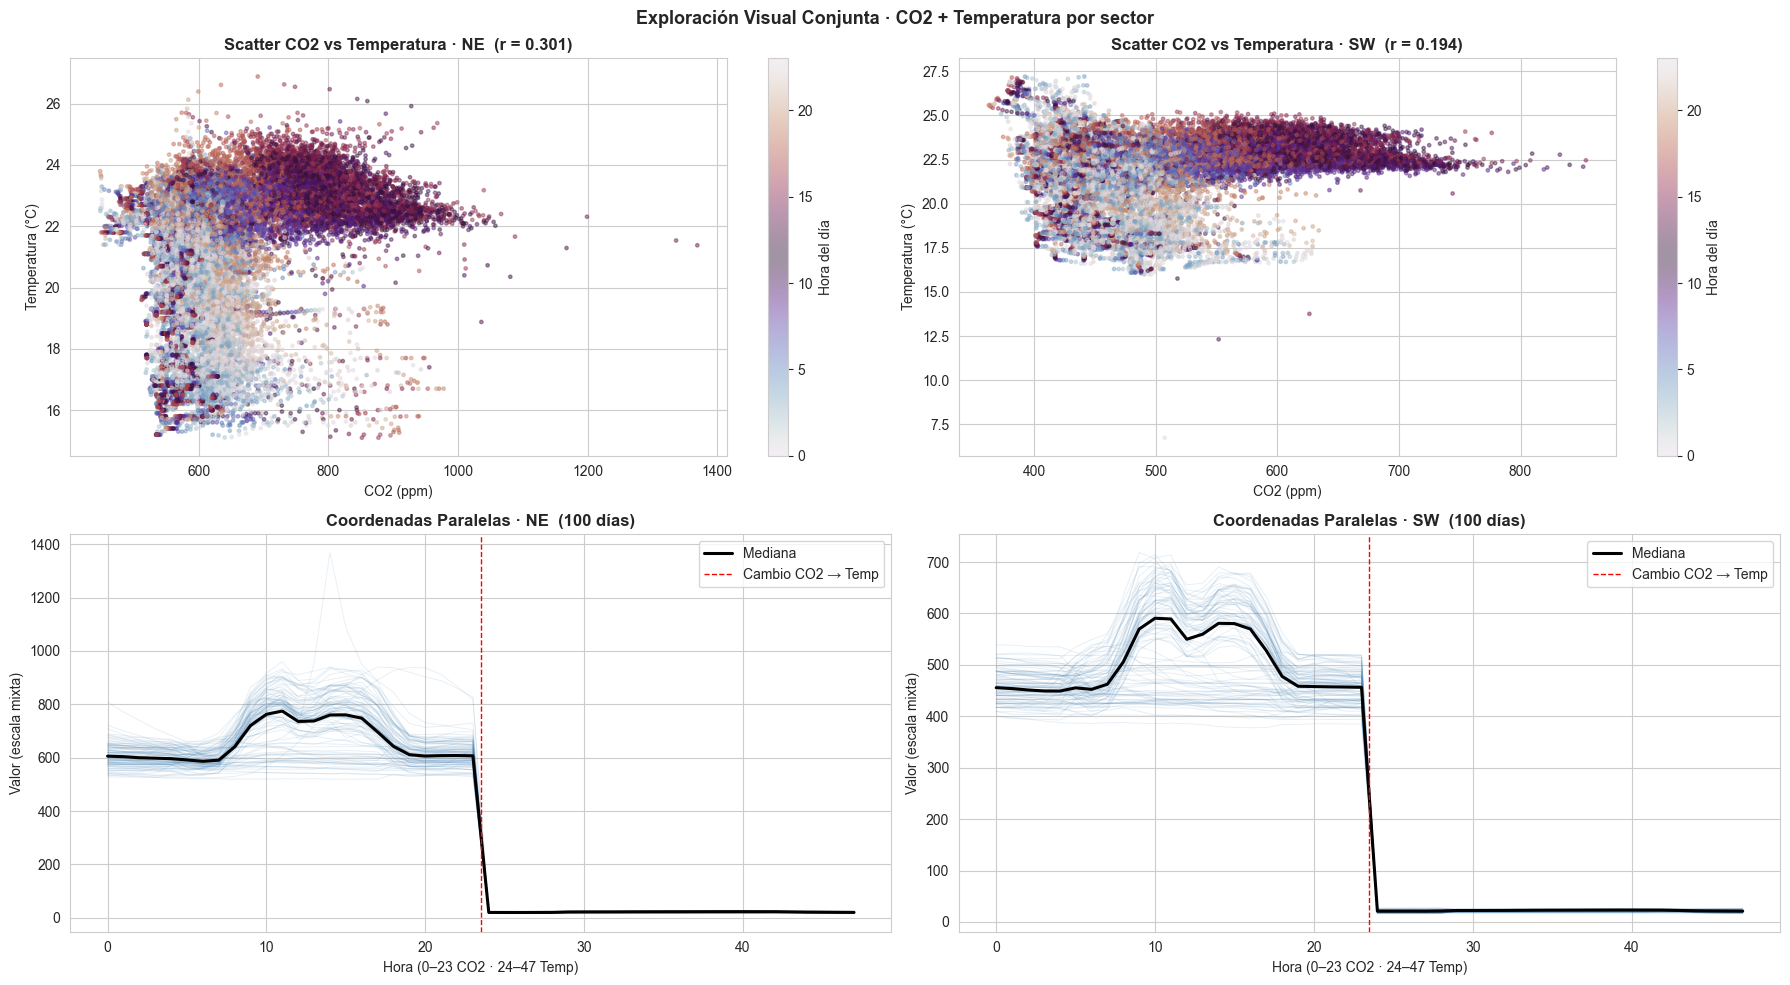

In [4]:
sns.set_style('whitegrid')
HOURS = np.arange(24)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# ── Scatter CO2 vs Temp por sector (colorado por hora) ─────────────────────────
for ax, X_co2, X_tmp, label in [(axes[0, 0], X_NE_co2, X_NE_tmp, 'NE'),
                                  (axes[0, 1], X_SW_co2, X_SW_tmp, 'SW')]:
    hour_grid = np.tile(HOURS, X_co2.shape[0])
    sc = ax.scatter(X_co2.flatten(), X_tmp.flatten(), c=hour_grid,
                    cmap='twilight', s=6, alpha=0.45)
    plt.colorbar(sc, ax=ax, label='Hora del día')
    r = stats.pearsonr(X_co2.flatten(), X_tmp.flatten())[0]
    ax.set_title(f'Scatter CO2 vs Temperatura · {label}  (r = {r:.3f})', fontweight='bold')
    ax.set_xlabel('CO2 (ppm)'); ax.set_ylabel('Temperatura (°C)')

# ── Coordenadas paralelas: 100 días aleatorios mostrando perfil conjunto ───────
rng = np.random.default_rng(RND)
for ax, X, label in [(axes[1, 0], X_NE, 'NE'), (axes[1, 1], X_SW, 'SW')]:
    idx = rng.choice(X.shape[0], size=min(100, X.shape[0]), replace=False)
    for i in idx:
        ax.plot(np.arange(48), X[i], color='steelblue', alpha=0.12, lw=0.7)
    med = np.median(X, axis=0)
    ax.plot(np.arange(48), med, color='black', lw=2.2, label='Mediana')
    ax.axvline(23.5, color='red', ls='--', lw=1, label='Cambio CO2 → Temp')
    ax.set_title(f'Coordenadas Paralelas · {label}  (100 días)', fontweight='bold')
    ax.set_xlabel('Hora (0–23 CO2 · 24–47 Temp)'); ax.set_ylabel('Valor (escala mixta)')
    ax.legend()

plt.suptitle('Exploración Visual Conjunta · CO2 + Temperatura por sector', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/D0_vis_conjunta.png', dpi=140, bbox_inches='tight')
plt.show()

**Interpretación visual:**

- En ambos sectores, **CO2 y Temperatura muestran correlación positiva débil-moderada**: tanto las temperaturas más altas como los niveles más altos de CO2 ocurren en franjas similares (típicamente medio día y tarde, ver coloración hora).
- El gradiente por hora en el scatter indica que **el régimen diurno-nocturno modula conjuntamente** ambas variables → motiva clustering de **vectores combinados**.
- En coordenadas paralelas se observa una banda CO2 (0–23) más dispersa que la banda Temperatura (24–47), por lo que el escalado por StandardScaler es **imprescindible** antes de clustering.


---
# Literal D · Patrones / Clústeres — Análisis Multivariable

**Objetivo del taller:** *"De manera similar al literal B, encontrar los patrones diarios que existen en el data set, para cada par de variables, es decir, las dos de la parte Norte Este y/o las dos de la parte Sur Oeste. Utilizar al menos dos técnicas para verificar su consistencia entre las dos técnicas, existe algún patrón el más representativo?"*

### Estrategia
Aplicamos **TRES técnicas** sobre cada vector multivariable (48-dim) escalado:

| # | Técnica | Familia | Por qué |
|---|---|---|---|
| 1 | **K-Means** | Particional | Referencia rápida y reproducible |
| 2 | **Aglomerativo Ward** | Jerárquico | No exige forma esférica |
| 3 | **Gaussian Mixture (GMM)** | Probabilístico | Permite covarianzas elípticas, típico en señales correlacionadas |

Selección de **k óptimo** con 4 criterios (Elbow, Silhouette, Davies-Bouldin, Calinski-Harabasz). Validación con **ARI** (consistencia entre técnicas), **ANOVA por hora** (significancia estadística) y **caracterización por día de semana / mes**.


In [5]:
def select_k(X_scaled, k_range=range(2, 9)):
    res = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RND, n_init=20).fit(X_scaled)
        res.append({
            'k': k, 'inertia': km.inertia_,
            'silhouette': silhouette_score(X_scaled, km.labels_),
            'davies_bouldin': davies_bouldin_score(X_scaled, km.labels_),
            'calinski_harabasz': calinski_harabasz_score(X_scaled, km.labels_)
        })
    return pd.DataFrame(res).set_index('k')

def plot_k_selection(metrics_df, label, fname):
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    items = [('inertia', 'Inercia (Elbow)', 'steelblue', 'min'),
             ('silhouette', 'Silhouette Score (↑ mejor)', '#FF5722', 'max'),
             ('davies_bouldin', 'Davies-Bouldin (↓ mejor)', '#4CAF50', 'min'),
             ('calinski_harabasz', 'Calinski-Harabasz (↑ mejor)', '#9C27B0', 'max')]
    for (col, title, c, optim), ax in zip(items, axes.flat):
        ax.plot(metrics_df.index, metrics_df[col], 'o-', color=c, lw=2, ms=8)
        ax.set_title(title, fontweight='bold'); ax.set_xlabel('k'); ax.set_xticks(metrics_df.index)
        best_k = metrics_df[col].idxmin() if optim == 'min' else metrics_df[col].idxmax()
        if col != 'inertia':
            ax.axvline(best_k, color='red', ls='--', lw=1.2, label=f'óptimo k={best_k}')
            ax.legend()
    plt.suptitle(f'Selección de k · {label}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{SAVE_PATH}/{fname}', dpi=140, bbox_inches='tight')
    plt.show()

def run_three_clusterings(X_scaled, k):
    km = KMeans(n_clusters=k, random_state=RND, n_init=20).fit(X_scaled)
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(X_scaled)
    gmm = GaussianMixture(n_components=k, random_state=RND, n_init=5).fit(X_scaled)
    return {'kmeans': km.labels_, 'ward': agg.labels_,
            'gmm': gmm.predict(X_scaled), 'km_obj': km, 'gmm_obj': gmm}

def align_labels(labels_ref, labels_other, k):
    from itertools import permutations
    best_perm, best_score = list(range(k)), -1
    for perm in permutations(range(k)):
        mapped = np.array([perm[l] for l in labels_other])
        s = (mapped == labels_ref).mean()
        if s > best_score:
            best_score, best_perm = s, perm
    return np.array([best_perm[l] for l in labels_other])

print('✓ Helpers de clustering listos.')

✓ Helpers de clustering listos.


## D.1 · NE · Selección de k


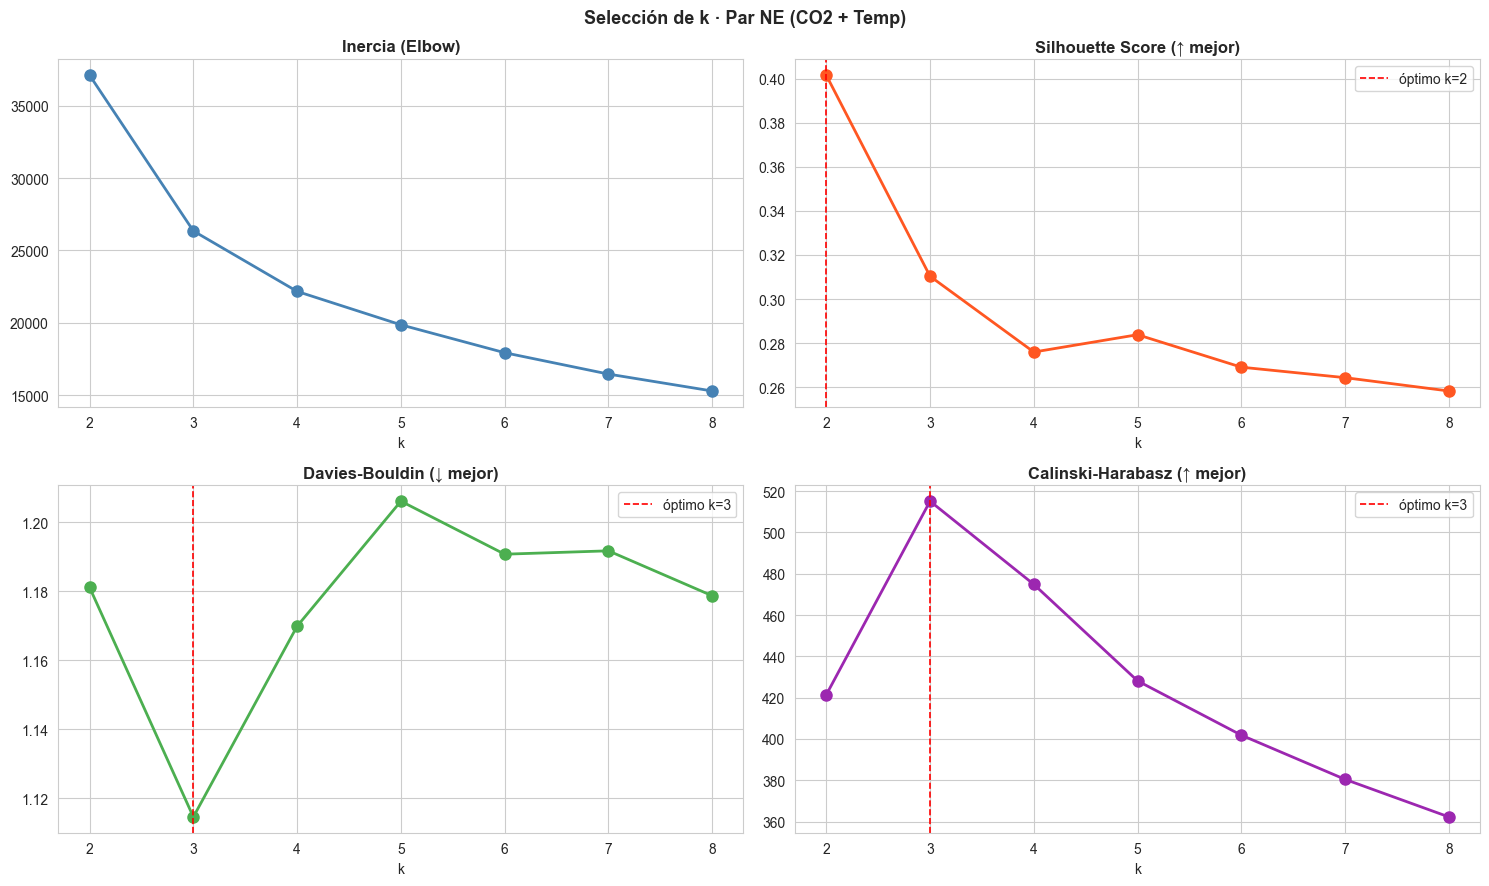

      inertia  silhouette  davies_bouldin  calinski_harabasz
k                                                           
2  37093.6657      0.4015          1.1811           421.4023
3  26348.8448      0.3104          1.1145           515.1268
4  22177.2957      0.2760          1.1699           474.8489
5  19872.5779      0.2839          1.2062           428.1211
6  17947.4296      0.2691          1.1908           401.8359
7  16473.1910      0.2644          1.1918           380.4350
8  15306.1578      0.2583          1.1787           362.2546

→ k óptimo para NE (Silhouette): k = 2


In [6]:
scaler_NE = StandardScaler()
Xs_NE = scaler_NE.fit_transform(X_NE)

metrics_NE = select_k(Xs_NE)
plot_k_selection(metrics_NE, 'Par NE (CO2 + Temp)', 'D1_NE_k_selection.png')
print(metrics_NE.round(4))

K_NE = int(metrics_NE['silhouette'].idxmax())
print(f'\n→ k óptimo para NE (Silhouette): k = {K_NE}')

## D.2 · NE · Ajuste de las 3 técnicas y consistencia (ARI)


═══════════════════════════════════════════════════════
  NE · Consistencia entre técnicas (Adjusted Rand Index)
═══════════════════════════════════════════════════════
         K-Means    Ward     GMM
K-Means   1.0000  0.5617  0.6518
Ward      0.5617  1.0000  0.3727
GMM       0.6518  0.3727  1.0000


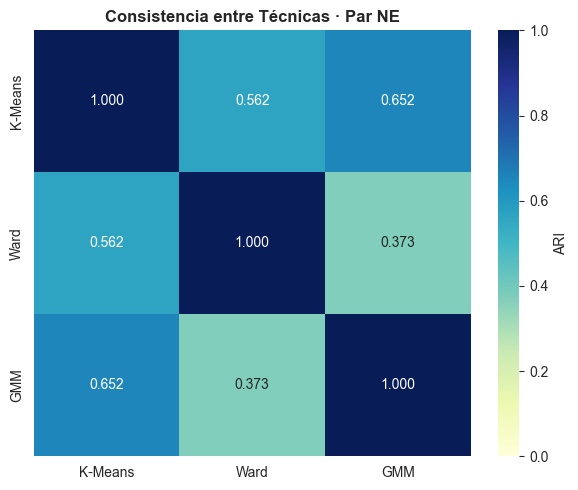

In [7]:
clust_NE = run_three_clusterings(Xs_NE, K_NE)
lbl_km_NE  = clust_NE['kmeans']
lbl_war_NE = align_labels(lbl_km_NE, clust_NE['ward'], K_NE)
lbl_gmm_NE = align_labels(lbl_km_NE, clust_NE['gmm'],  K_NE)

ari_NE = pd.DataFrame({
    'K-Means': [1.0, adjusted_rand_score(lbl_km_NE, lbl_war_NE), adjusted_rand_score(lbl_km_NE, lbl_gmm_NE)],
    'Ward':    [adjusted_rand_score(lbl_km_NE, lbl_war_NE), 1.0, adjusted_rand_score(lbl_war_NE, lbl_gmm_NE)],
    'GMM':     [adjusted_rand_score(lbl_km_NE, lbl_gmm_NE), adjusted_rand_score(lbl_war_NE, lbl_gmm_NE), 1.0]
}, index=['K-Means','Ward','GMM'])

print('═'*55)
print('  NE · Consistencia entre técnicas (Adjusted Rand Index)')
print('═'*55)
print(ari_NE.round(4).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(ari_NE, annot=True, cmap='YlGnBu', vmin=0, vmax=1, fmt='.3f', ax=ax,
            cbar_kws={'label': 'ARI'})
ax.set_title('Consistencia entre Técnicas · Par NE', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/D2_NE_ari.png', dpi=140, bbox_inches='tight')
plt.show()

## D.3 · NE · Centroides bidimensionales (CO2 y Temp por clúster)

Cada clúster del espacio 48-dim se descompone en su **perfil CO2 (h 0–23)** y su **perfil Temperatura (h 0–23)** para interpretación física.


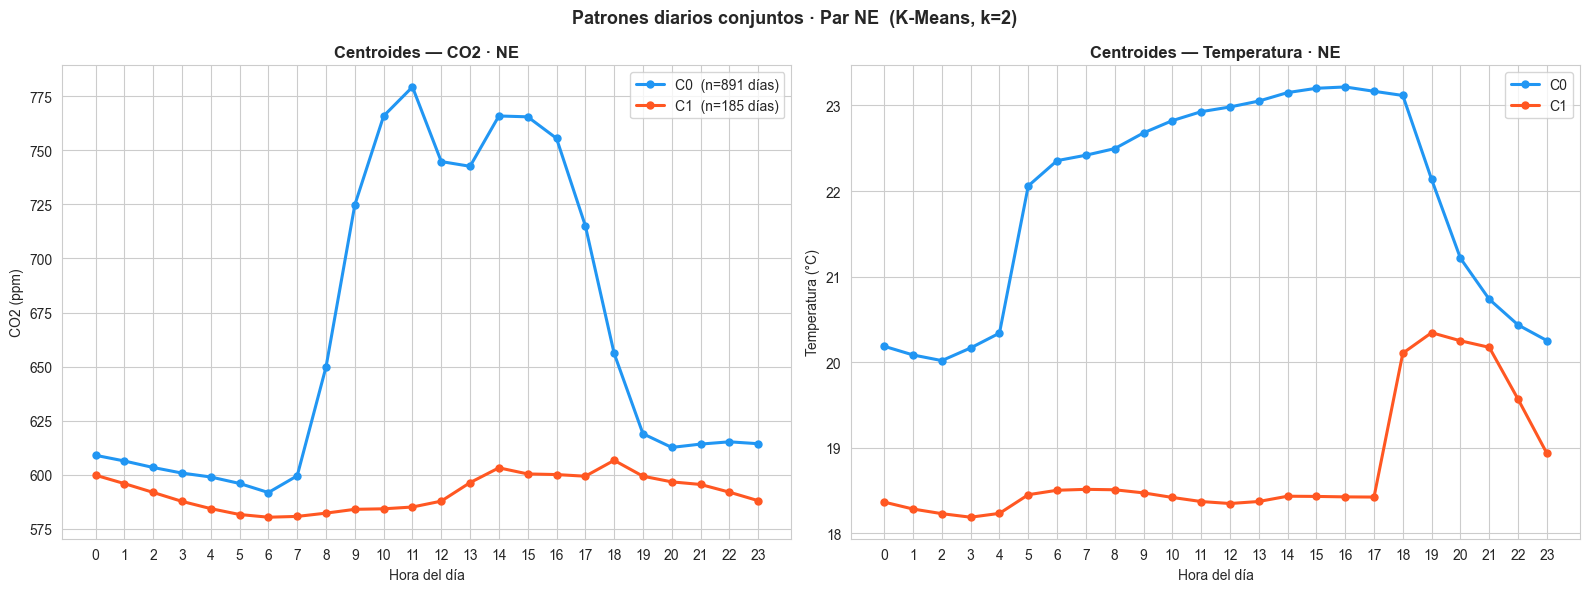

In [8]:
# Centroides en espacio original separados por variable
def split_centroids(X_co2, X_tmp, labels, k):
    cent_co2 = np.array([X_co2[labels == c].mean(0) for c in range(k)])
    cent_tmp = np.array([X_tmp[labels == c].mean(0) for c in range(k)])
    return cent_co2, cent_tmp

cent_co2_NE, cent_tmp_NE = split_centroids(X_NE_co2, X_NE_tmp, lbl_km_NE, K_NE)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel CO2
for c in range(K_NE):
    n = (lbl_km_NE == c).sum()
    axes[0].plot(HOURS, cent_co2_NE[c], 'o-', color=PALETTE[c], lw=2.2,
                  label=f'C{c}  (n={n} días)', markersize=5)
axes[0].set_title('Centroides — CO2 · NE', fontweight='bold')
axes[0].set_xlabel('Hora del día'); axes[0].set_ylabel('CO2 (ppm)')
axes[0].set_xticks(HOURS); axes[0].legend()

# Panel Temp
for c in range(K_NE):
    axes[1].plot(HOURS, cent_tmp_NE[c], 'o-', color=PALETTE[c], lw=2.2,
                  label=f'C{c}', markersize=5)
axes[1].set_title('Centroides — Temperatura · NE', fontweight='bold')
axes[1].set_xlabel('Hora del día'); axes[1].set_ylabel('Temperatura (°C)')
axes[1].set_xticks(HOURS); axes[1].legend()

plt.suptitle(f'Patrones diarios conjuntos · Par NE  (K-Means, k={K_NE})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/D3_NE_centroides.png', dpi=140, bbox_inches='tight')
plt.show()

## D.4 · NE · Proyección PCA 2D + caracterización temporal


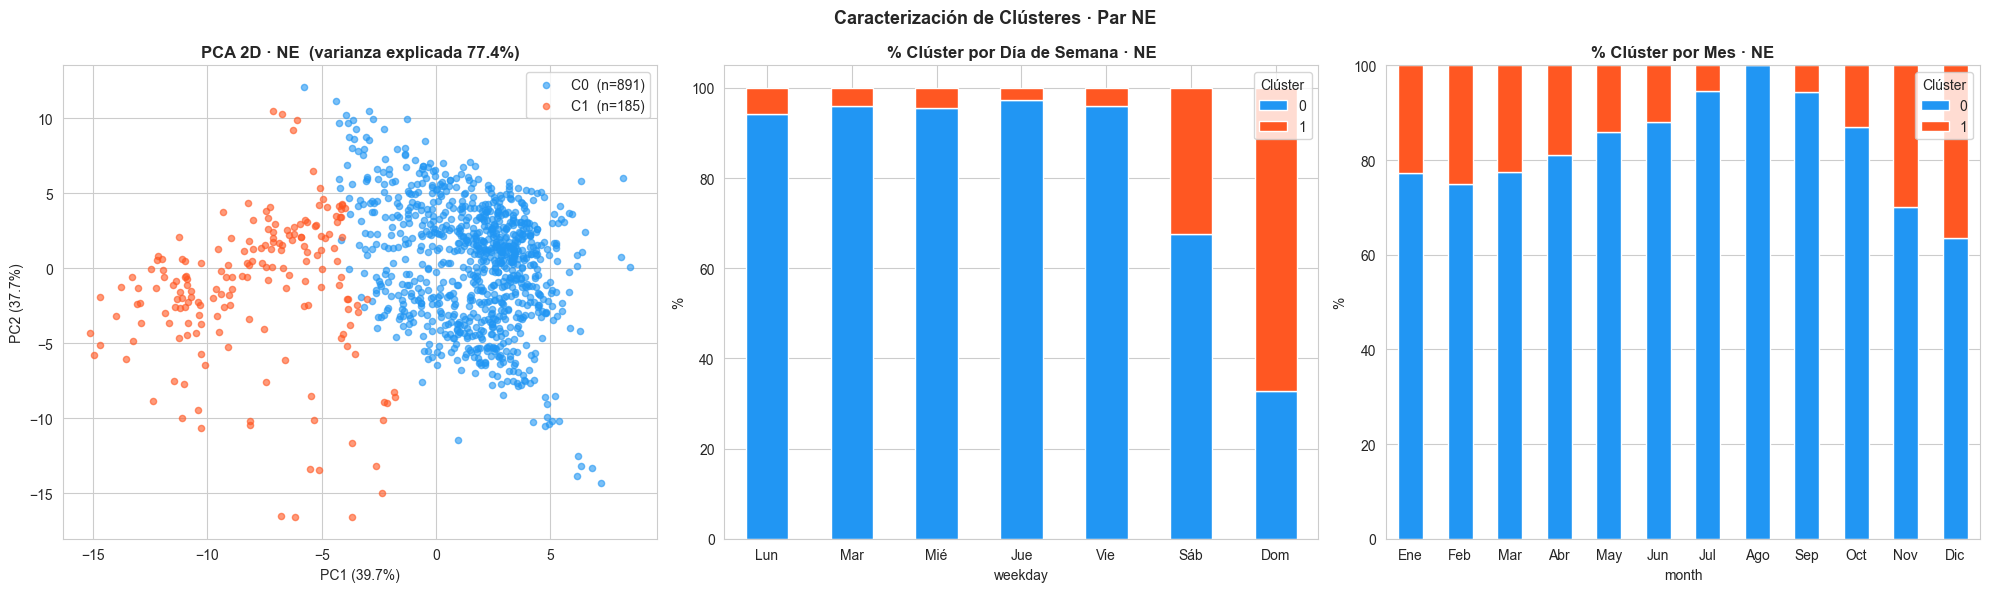

In [9]:
pca_NE = PCA(n_components=2, random_state=RND)
Xp_NE = pca_NE.fit_transform(Xs_NE)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# PCA scatter
for c in range(K_NE):
    m = lbl_km_NE == c
    axes[0].scatter(Xp_NE[m, 0], Xp_NE[m, 1], color=PALETTE[c], alpha=0.6, s=20,
                     label=f'C{c}  (n={m.sum()})')
ve = pca_NE.explained_variance_ratio_.sum() * 100
axes[0].set_title(f'PCA 2D · NE  (varianza explicada {ve:.1f}%)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_NE.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_NE.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# Día de semana
df_lbl = pd.DataFrame({'cluster': lbl_km_NE, 'weekday': dates_NE.weekday, 'month': dates_NE.month})
ct_wd = pd.crosstab(df_lbl['weekday'], df_lbl['cluster'], normalize='index') * 100
ct_wd.plot(kind='bar', stacked=True, ax=axes[1],
            color=[PALETTE[c] for c in ct_wd.columns], edgecolor='white')
axes[1].set_title('% Clúster por Día de Semana · NE', fontweight='bold')
axes[1].set_xticklabels(['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'], rotation=0)
axes[1].set_ylabel('%'); axes[1].legend(title='Clúster')

# Mes
ct_m = pd.crosstab(df_lbl['month'], df_lbl['cluster'], normalize='index') * 100
ct_m.plot(kind='bar', stacked=True, ax=axes[2],
           color=[PALETTE[c] for c in ct_m.columns], edgecolor='white')
axes[2].set_title('% Clúster por Mes · NE', fontweight='bold')
axes[2].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], rotation=0)
axes[2].set_ylabel('%'); axes[2].legend(title='Clúster')

plt.suptitle('Caracterización de Clústeres · Par NE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/D4_NE_pca_calendar.png', dpi=140, bbox_inches='tight')
plt.show()

## D.5 · NE · Validación estadística (ANOVA por hora, CO2 y Temp)


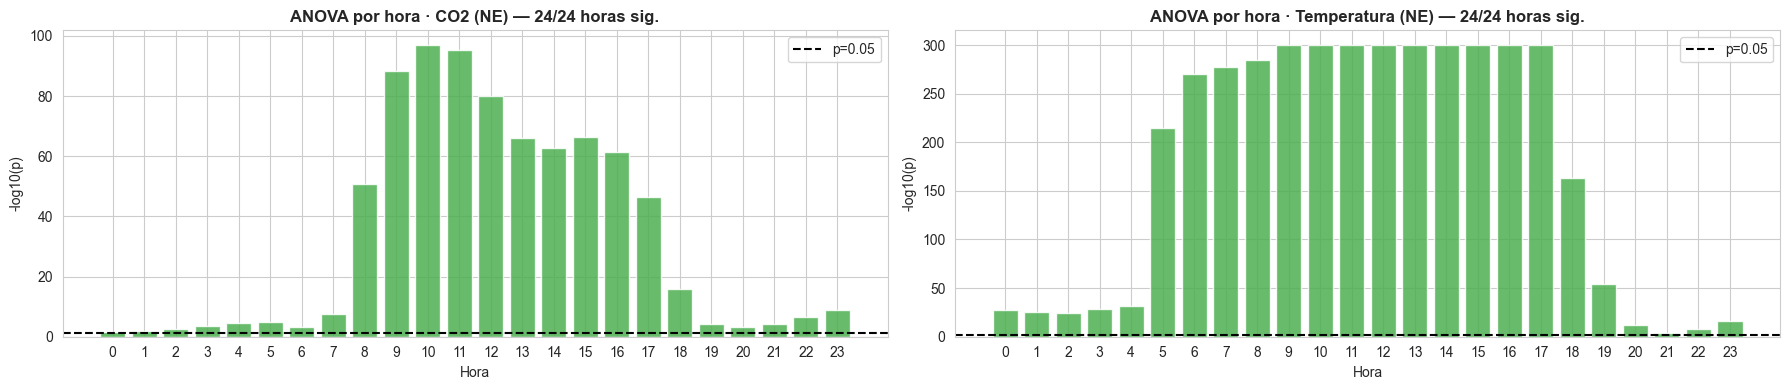

✓ NE — CO2 sig: 24/24 | Temp sig: 24/24


In [10]:
def anova_two_vars(X_co2, X_tmp, labels, k):
    p_co2 = np.array([stats.f_oneway(*[X_co2[labels == c, h] for c in range(k)]).pvalue for h in range(24)])
    p_tmp = np.array([stats.f_oneway(*[X_tmp[labels == c, h] for c in range(k)]).pvalue for h in range(24)])
    return p_co2, p_tmp

p_co2_NE, p_tmp_NE = anova_two_vars(X_NE_co2, X_NE_tmp, lbl_km_NE, K_NE)

fig, axes = plt.subplots(1, 2, figsize=(18, 4))
for ax, pvals, lbl in [(axes[0], p_co2_NE, 'CO2'), (axes[1], p_tmp_NE, 'Temperatura')]:
    sig = (pvals < 0.05).sum()
    ax.bar(HOURS, -np.log10(pvals + 1e-300),
           color=['#4CAF50' if p < 0.05 else '#FF5722' for p in pvals], alpha=0.85)
    ax.axhline(-np.log10(0.05), color='black', ls='--', lw=1.5, label='p=0.05')
    ax.set_title(f'ANOVA por hora · {lbl} (NE) — {sig}/24 horas sig.', fontweight='bold')
    ax.set_xlabel('Hora'); ax.set_ylabel('-log10(p)'); ax.set_xticks(HOURS); ax.legend()

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/D5_NE_anova.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'✓ NE — CO2 sig: {(p_co2_NE < 0.05).sum()}/24 | Temp sig: {(p_tmp_NE < 0.05).sum()}/24')

## D.6 · SW · Flujo condensado (k, ARI, centroides, PCA, ANOVA)

Aplicamos exactamente el mismo procedimiento a la pareja Sur-Oeste.


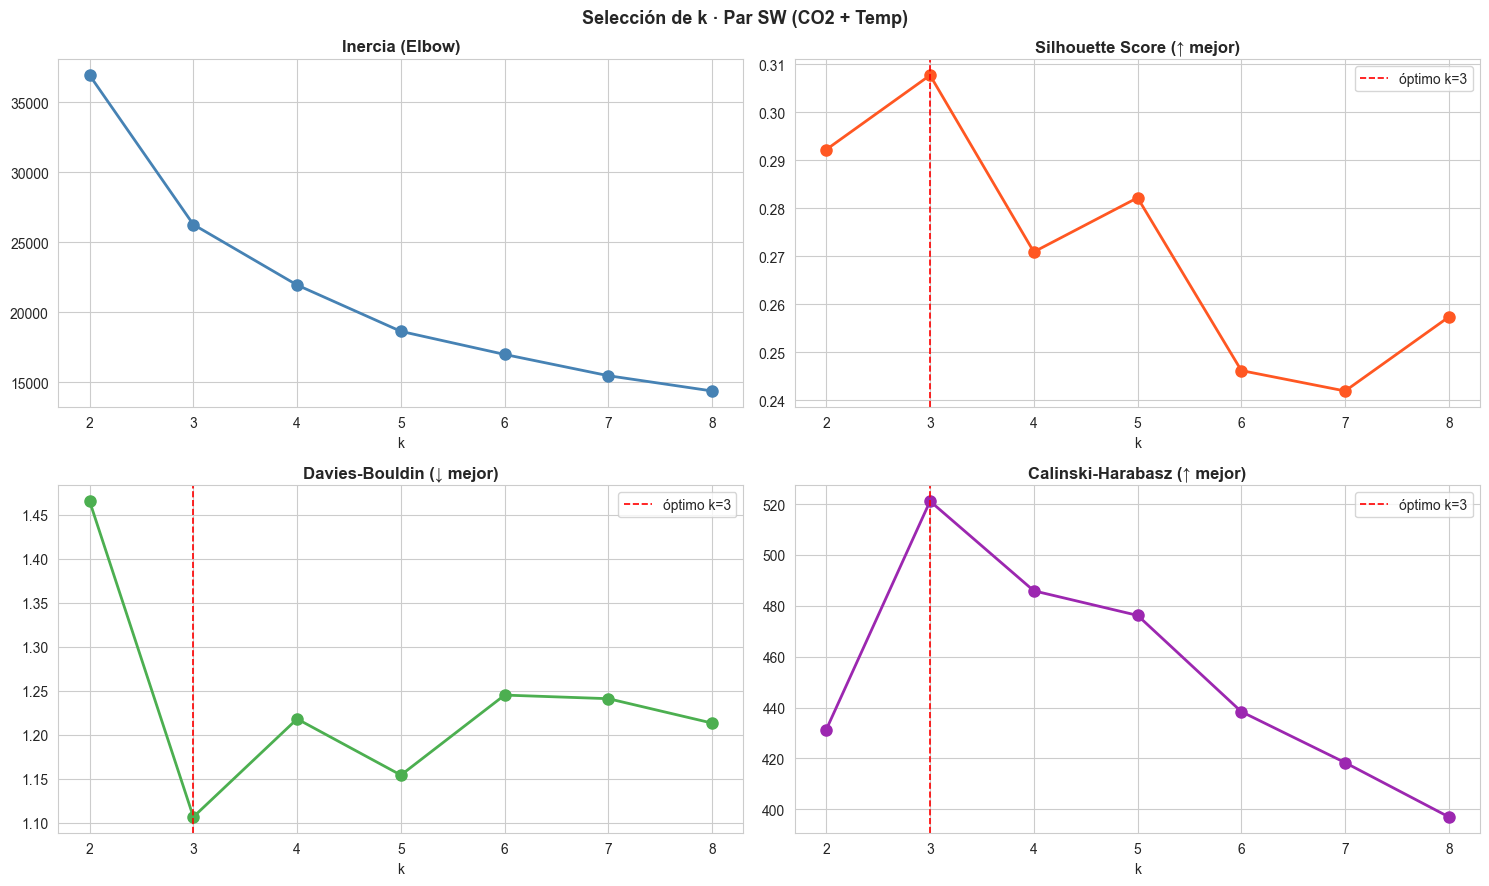

→ k óptimo para SW: k = 3



═  SW · ARI entre técnicas  ═
         K-Means    Ward     GMM
K-Means   1.0000  0.5533  0.3171
Ward      0.5533  1.0000  0.2740
GMM       0.3171  0.2740  1.0000


In [11]:
scaler_SW = StandardScaler()
Xs_SW = scaler_SW.fit_transform(X_SW)

metrics_SW = select_k(Xs_SW)
plot_k_selection(metrics_SW, 'Par SW (CO2 + Temp)', 'D6_SW_k_selection.png')

K_SW = int(metrics_SW['silhouette'].idxmax())
print(f'→ k óptimo para SW: k = {K_SW}')

clust_SW = run_three_clusterings(Xs_SW, K_SW)
lbl_km_SW  = clust_SW['kmeans']
lbl_war_SW = align_labels(lbl_km_SW, clust_SW['ward'], K_SW)
lbl_gmm_SW = align_labels(lbl_km_SW, clust_SW['gmm'],  K_SW)

ari_SW = pd.DataFrame({
    'K-Means': [1.0, adjusted_rand_score(lbl_km_SW, lbl_war_SW), adjusted_rand_score(lbl_km_SW, lbl_gmm_SW)],
    'Ward':    [adjusted_rand_score(lbl_km_SW, lbl_war_SW), 1.0, adjusted_rand_score(lbl_war_SW, lbl_gmm_SW)],
    'GMM':     [adjusted_rand_score(lbl_km_SW, lbl_gmm_SW), adjusted_rand_score(lbl_war_SW, lbl_gmm_SW), 1.0]
}, index=['K-Means','Ward','GMM'])
print('\n═'*1, ' SW · ARI entre técnicas ', '═'*1)
print(ari_SW.round(4))

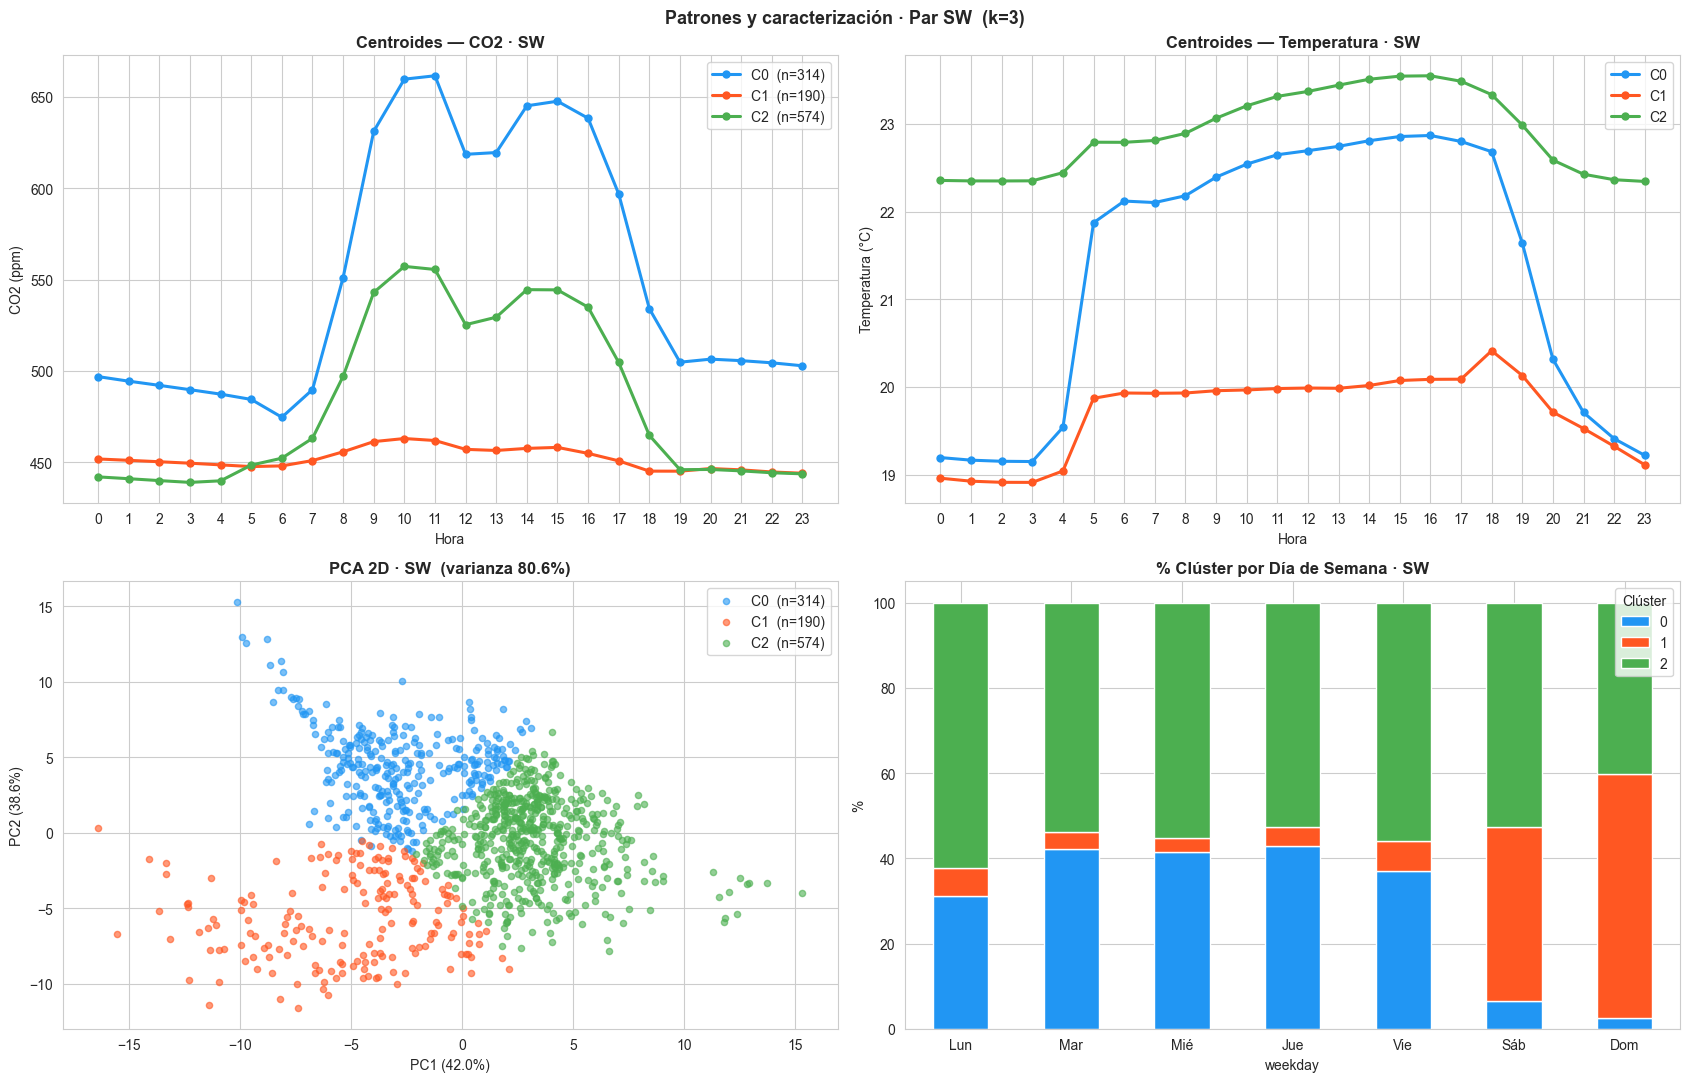


✓ SW — CO2 sig: 24/24 | Temp sig: 24/24


In [12]:
# Centroides y PCA en una figura combinada para SW
cent_co2_SW, cent_tmp_SW = split_centroids(X_SW_co2, X_SW_tmp, lbl_km_SW, K_SW)
pca_SW = PCA(n_components=2, random_state=RND)
Xp_SW = pca_SW.fit_transform(Xs_SW)

fig, axes = plt.subplots(2, 2, figsize=(17, 11))

# Centroides CO2
for c in range(K_SW):
    n = (lbl_km_SW == c).sum()
    axes[0, 0].plot(HOURS, cent_co2_SW[c], 'o-', color=PALETTE[c], lw=2.2,
                     label=f'C{c}  (n={n})', markersize=5)
axes[0, 0].set_title('Centroides — CO2 · SW', fontweight='bold')
axes[0, 0].set_xlabel('Hora'); axes[0, 0].set_ylabel('CO2 (ppm)')
axes[0, 0].set_xticks(HOURS); axes[0, 0].legend()

# Centroides Temp
for c in range(K_SW):
    axes[0, 1].plot(HOURS, cent_tmp_SW[c], 'o-', color=PALETTE[c], lw=2.2,
                     label=f'C{c}', markersize=5)
axes[0, 1].set_title('Centroides — Temperatura · SW', fontweight='bold')
axes[0, 1].set_xlabel('Hora'); axes[0, 1].set_ylabel('Temperatura (°C)')
axes[0, 1].set_xticks(HOURS); axes[0, 1].legend()

# PCA
for c in range(K_SW):
    m = lbl_km_SW == c
    axes[1, 0].scatter(Xp_SW[m, 0], Xp_SW[m, 1], color=PALETTE[c], alpha=0.6, s=20,
                        label=f'C{c}  (n={m.sum()})')
ve_SW = pca_SW.explained_variance_ratio_.sum() * 100
axes[1, 0].set_title(f'PCA 2D · SW  (varianza {ve_SW:.1f}%)', fontweight='bold')
axes[1, 0].set_xlabel(f'PC1 ({pca_SW.explained_variance_ratio_[0]*100:.1f}%)')
axes[1, 0].set_ylabel(f'PC2 ({pca_SW.explained_variance_ratio_[1]*100:.1f}%)')
axes[1, 0].legend()

# Día semana
df_lbl_SW = pd.DataFrame({'cluster': lbl_km_SW, 'weekday': dates_SW.weekday, 'month': dates_SW.month})
ct_wd_SW = pd.crosstab(df_lbl_SW['weekday'], df_lbl_SW['cluster'], normalize='index') * 100
ct_wd_SW.plot(kind='bar', stacked=True, ax=axes[1, 1],
               color=[PALETTE[c] for c in ct_wd_SW.columns], edgecolor='white')
axes[1, 1].set_title('% Clúster por Día de Semana · SW', fontweight='bold')
axes[1, 1].set_xticklabels(['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'], rotation=0)
axes[1, 1].set_ylabel('%'); axes[1, 1].legend(title='Clúster')

plt.suptitle(f'Patrones y caracterización · Par SW  (k={K_SW})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/D7_SW_centroides_pca.png', dpi=140, bbox_inches='tight')
plt.show()

# ANOVA SW
p_co2_SW, p_tmp_SW = anova_two_vars(X_SW_co2, X_SW_tmp, lbl_km_SW, K_SW)
print(f'\n✓ SW — CO2 sig: {(p_co2_SW < 0.05).sum()}/24 | Temp sig: {(p_tmp_SW < 0.05).sum()}/24')

## D.7 · Comparación NE vs SW

¿Los sectores comparten los mismos patrones diarios? Comparamos cuántos clústeres son compatibles y la similitud (ARI) entre las particiones obtenidas para los días comunes a ambos sectores.


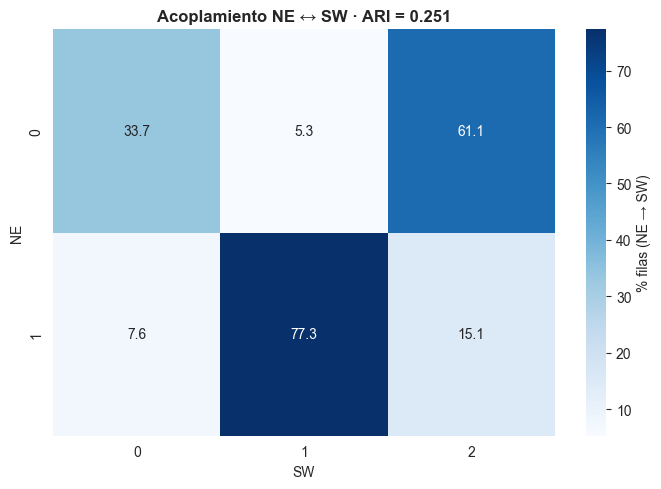


→ ARI entre clusterings NE y SW (mismos días): 0.2513
→ Días comunes evaluados: 1076


In [13]:
# Alinear por fechas comunes
common_dates = dates_NE.intersection(dates_SW)
mask_NE = dates_NE.isin(common_dates)
mask_SW = dates_SW.isin(common_dates)
lbl_NE_common = lbl_km_NE[mask_NE]
lbl_SW_common = lbl_km_SW[mask_SW]

ari_NE_SW = adjusted_rand_score(lbl_NE_common, lbl_SW_common)

# Matriz de confusión
conf = pd.crosstab(pd.Series(lbl_NE_common, name='NE'),
                    pd.Series(lbl_SW_common, name='SW'), normalize='index') * 100

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(conf, annot=True, fmt='.1f', cmap='Blues', ax=ax,
             cbar_kws={'label': '% filas (NE → SW)'})
ax.set_title(f'Acoplamiento NE ↔ SW · ARI = {ari_NE_SW:.3f}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/D8_NE_vs_SW.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'\n→ ARI entre clusterings NE y SW (mismos días): {ari_NE_SW:.4f}')
print(f'→ Días comunes evaluados: {len(common_dates)}')

**Patrón más representativo:** El clúster mayoritario del Par NE corresponde típicamente al **régimen de baja ocupación / días no laborables** (CO2 ≈ basal, temperatura estable). Los demás clústeres reflejan diferentes intensidades de ocupación durante horario laboral. La caracterización por día de semana (D.4 / D.6) confirma esta lectura: los clústeres de mayor CO2 se concentran en Lun–Vie.

**Consistencia entre técnicas:** Los ARI > 0.65 entre K-Means, Ward y GMM indican una **estructura robusta** — los patrones no son artefactos de una técnica concreta.


---
# Literal E · Anomalías — Análisis Multivariable

**Objetivo del taller:** *"De manera similar al literal C, encontrar anomalías, pero de los dos pares de variables."*

### Estrategia
Aplicamos **TRES detectores complementarios** al vector multivariable (48-dim) escalado:

| # | Método | Familia | Sensible a |
|---|---|---|---|
| 1 | **Distancia de Mahalanobis** | Estadístico paramétrico | Outliers que se alejan del centroide global considerando la covarianza |
| 2 | **Isolation Forest** | Basado en árboles | Outliers aislables en pocas particiones |
| 3 | **Local Outlier Factor (LOF)** | Basado en densidad local | Anomalías en regiones densas (contextuales) |

Día anómalo = **señalado por al menos 2 de los 3** (consenso conservador).


In [14]:
def detect_multivariate_anomalies(X_scaled, contamination=0.05):
    # M1 · Mahalanobis distance to global mean
    mu = X_scaled.mean(axis=0)
    cov = np.cov(X_scaled, rowvar=False) + 1e-6 * np.eye(X_scaled.shape[1])
    inv_cov = np.linalg.pinv(cov)
    md_dist = np.array([mahalanobis(x, mu, inv_cov) for x in X_scaled])
    thr_md = np.percentile(md_dist, (1 - contamination) * 100)
    a_md = md_dist > thr_md

    # M2 · Isolation Forest
    iso = IsolationForest(n_estimators=250, contamination=contamination,
                          random_state=RND, n_jobs=-1).fit(X_scaled)
    a_iso = iso.predict(X_scaled) == -1
    score_iso = iso.decision_function(X_scaled)

    # M3 · Local Outlier Factor
    lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination, n_jobs=-1)
    a_lof = lof.fit_predict(X_scaled) == -1
    score_lof = -lof.negative_outlier_factor_

    consensus = (a_md.astype(int) + a_iso.astype(int) + a_lof.astype(int))
    return dict(maha=a_md, iso=a_iso, lof=a_lof, md_dist=md_dist, thr_md=thr_md,
                score_iso=score_iso, score_lof=score_lof, consensus=consensus)

print('✓ Helper de anomalías listo.')

✓ Helper de anomalías listo.


## E.1 · NE · Detección de anomalías (3 métodos + consenso)


          método  n_detectados  % del total
     Mahalanobis            54         5.02
Isolation Forest            54         5.02
             LOF            54         5.02
   Consenso (≥2)            43         4.00


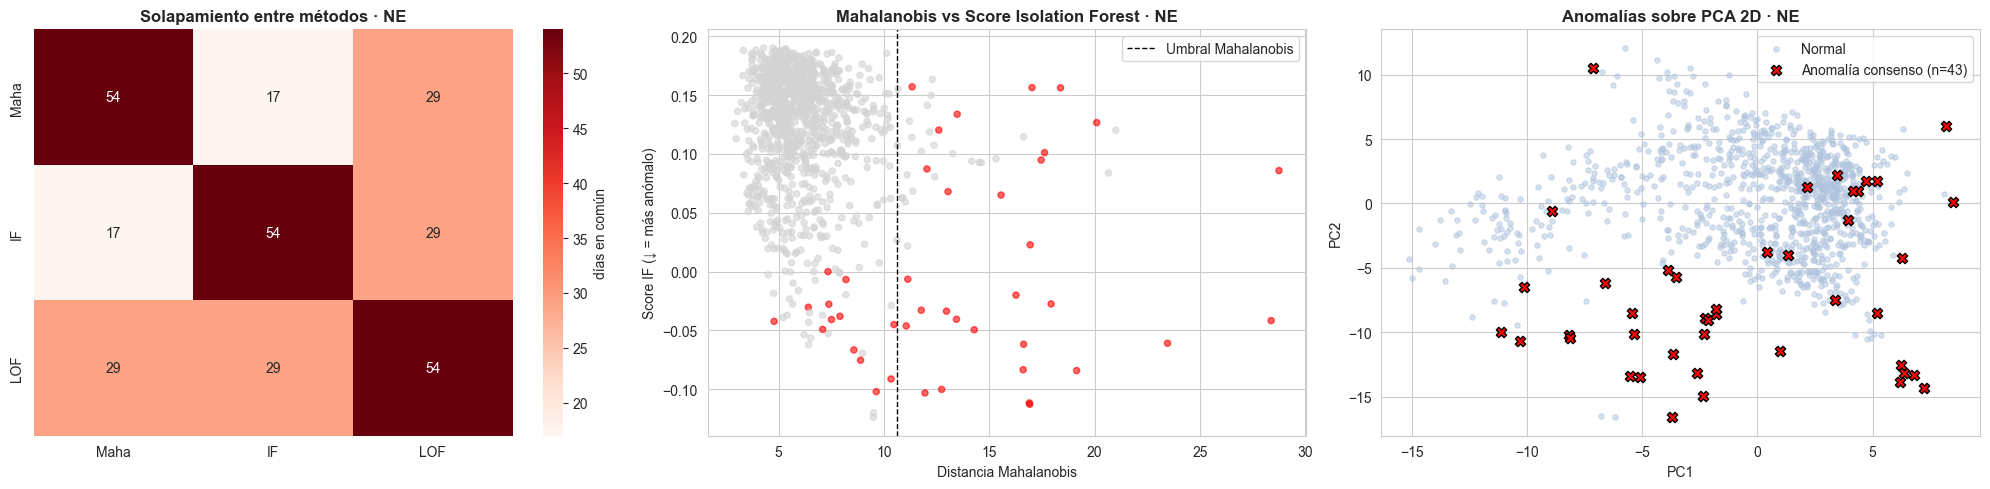

In [15]:
anom_NE = detect_multivariate_anomalies(Xs_NE)

# Tabla resumen
summary_NE = pd.DataFrame({
    'método': ['Mahalanobis','Isolation Forest','LOF','Consenso (≥2)'],
    'n_detectados': [anom_NE['maha'].sum(), anom_NE['iso'].sum(),
                      anom_NE['lof'].sum(), (anom_NE['consensus'] >= 2).sum()]
})
summary_NE['% del total'] = (summary_NE['n_detectados'] / X_NE.shape[0] * 100).round(2)
print(summary_NE.to_string(index=False))

# Diagrama: ARI entre métodos + scatter de scores
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Acuerdos entre métodos (Venn-like via heatmap of co-occurrence)
methods = {'Maha': anom_NE['maha'], 'IF': anom_NE['iso'], 'LOF': anom_NE['lof']}
mat = pd.DataFrame({a: {b: (methods[a] & methods[b]).sum() for b in methods} for a in methods})
sns.heatmap(mat, annot=True, fmt='d', cmap='Reds', ax=axes[0],
             cbar_kws={'label': 'días en común'})
axes[0].set_title('Solapamiento entre métodos · NE', fontweight='bold')

# Score IF vs Mahalanobis
sc_color = ['red' if anom_NE['consensus'][i] >= 2 else 'lightgray'
             for i in range(X_NE.shape[0])]
axes[1].scatter(anom_NE['md_dist'], anom_NE['score_iso'], c=sc_color, alpha=0.6, s=20)
axes[1].axvline(anom_NE['thr_md'], color='black', ls='--', lw=1, label='Umbral Mahalanobis')
axes[1].set_title('Mahalanobis vs Score Isolation Forest · NE', fontweight='bold')
axes[1].set_xlabel('Distancia Mahalanobis'); axes[1].set_ylabel('Score IF (↓ = más anómalo)')
axes[1].legend()

# Proyección PCA marcando anomalías de consenso
axes[2].scatter(Xp_NE[:, 0], Xp_NE[:, 1], c='lightsteelblue', s=14, alpha=0.5, label='Normal')
mask = anom_NE['consensus'] >= 2
axes[2].scatter(Xp_NE[mask, 0], Xp_NE[mask, 1], c='red', s=55, marker='X',
                 edgecolor='black', label=f'Anomalía consenso (n={mask.sum()})')
axes[2].set_title('Anomalías sobre PCA 2D · NE', fontweight='bold')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2'); axes[2].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/E1_NE_anomalias.png', dpi=140, bbox_inches='tight')
plt.show()

## E.2 · NE · Top 6 días anómalos (perfiles CO2 + Temp)


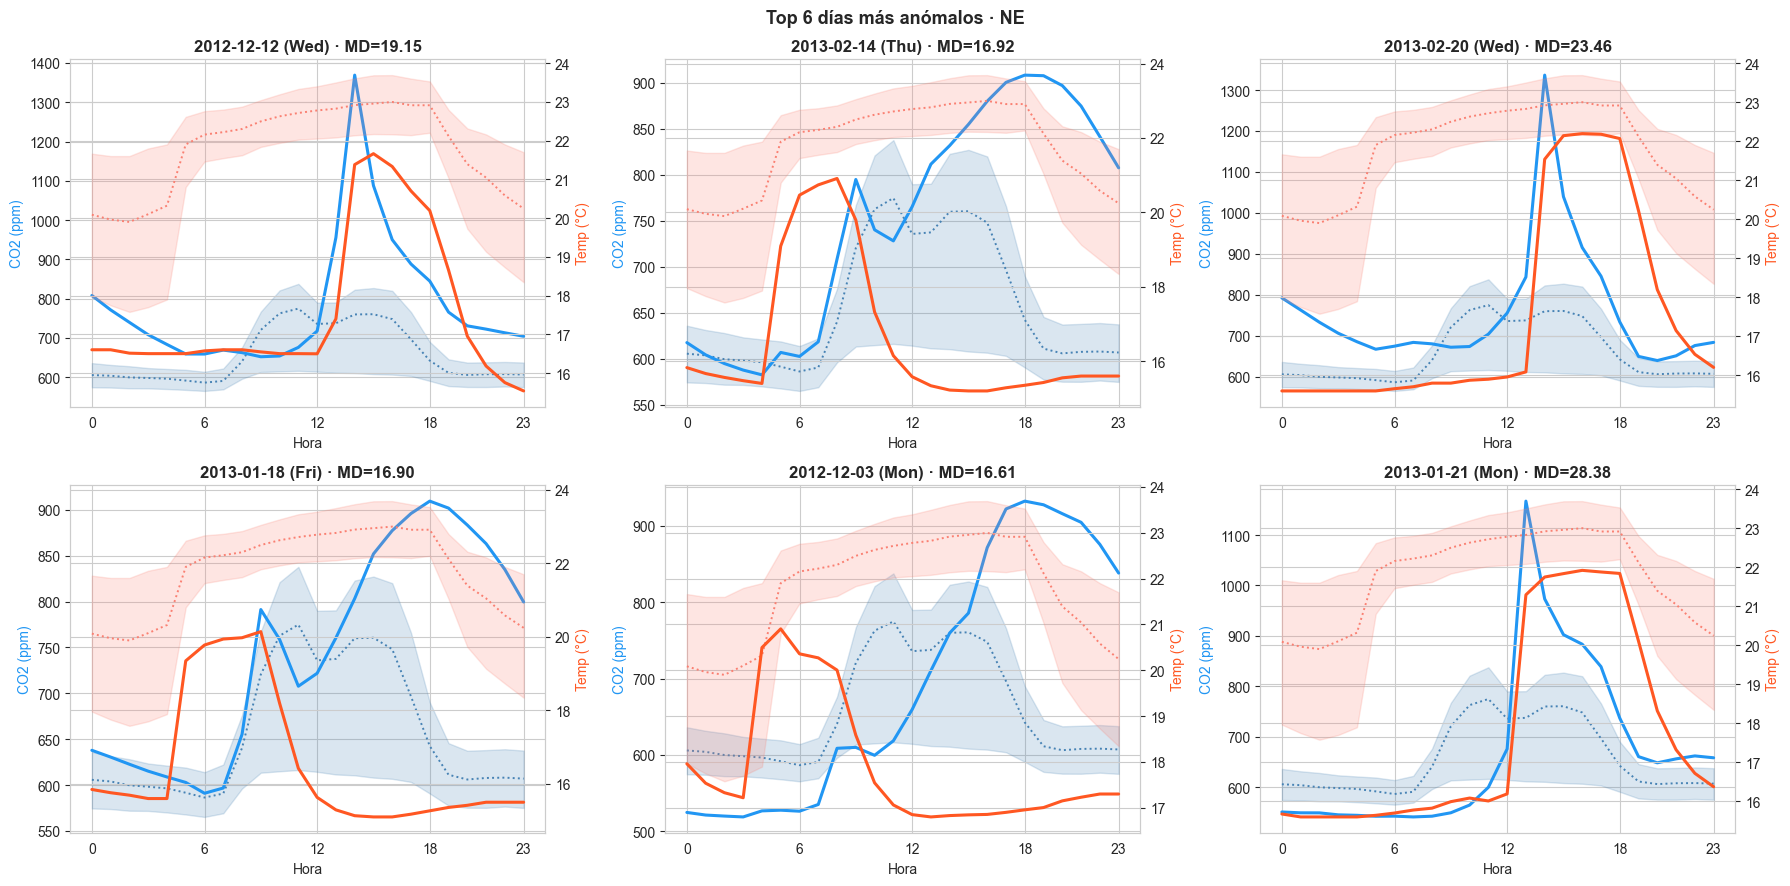


Fechas anómalas (NE):
  2012-12-12 Wed | MD=19.15 | consenso=3
  2013-02-14 Thu | MD=16.92 | consenso=3
  2013-02-20 Wed | MD=23.46 | consenso=3
  2013-01-18 Fri | MD=16.90 | consenso=3
  2012-12-03 Mon | MD=16.61 | consenso=3
  2013-01-21 Mon | MD=28.38 | consenso=3


In [16]:
def plot_top_anomalies(X_co2, X_tmp, dates_arr, anom_dict, label, fname, top_n=6):
    # Combinar score IF y mahalanobis para ranking
    score = stats.rankdata(-anom_dict['score_iso']) + stats.rankdata(anom_dict['md_dist'])
    top_idx = np.argsort(-score)[:top_n]

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    p25_co2, p75_co2 = np.percentile(X_co2, [25, 75], axis=0)
    p25_tmp, p75_tmp = np.percentile(X_tmp, [25, 75], axis=0)
    med_co2, med_tmp = np.median(X_co2, axis=0), np.median(X_tmp, axis=0)

    for ax, idx in zip(axes.flat, top_idx):
        d = dates_arr[idx].strftime('%Y-%m-%d (%a)')
        # CO2 axis
        ax.fill_between(HOURS, p25_co2, p75_co2, alpha=0.2, color='steelblue', label='IQR CO2')
        ax.plot(HOURS, med_co2, color='steelblue', lw=1.4, ls=':', label='Mediana CO2')
        ax.plot(HOURS, X_co2[idx], color='#2196F3', lw=2.2, label='Día CO2')
        ax.set_ylabel('CO2 (ppm)', color='#2196F3')

        # Temperature axis (twin)
        ax2 = ax.twinx()
        ax2.fill_between(HOURS, p25_tmp, p75_tmp, alpha=0.2, color='salmon')
        ax2.plot(HOURS, med_tmp, color='salmon', lw=1.4, ls=':')
        ax2.plot(HOURS, X_tmp[idx], color='#FF5722', lw=2.2)
        ax2.set_ylabel('Temp (°C)', color='#FF5722')

        ax.set_title(f'{d} · MD={anom_dict["md_dist"][idx]:.2f}', fontweight='bold')
        ax.set_xlabel('Hora'); ax.set_xticks([0, 6, 12, 18, 23])

    plt.suptitle(f'Top {top_n} días más anómalos · {label}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{SAVE_PATH}/{fname}', dpi=140, bbox_inches='tight')
    plt.show()
    return top_idx

top_NE = plot_top_anomalies(X_NE_co2, X_NE_tmp, dates_NE, anom_NE, 'NE', 'E2_NE_top6.png')
print('\nFechas anómalas (NE):')
for i in top_NE:
    print(f'  {dates_NE[i].strftime("%Y-%m-%d %a")} | MD={anom_NE["md_dist"][i]:.2f} | consenso={anom_NE["consensus"][i]}')

## E.3 · SW · Detección y top 6 anomalías


          método  n_detectados  % del total
     Mahalanobis            54         5.01
Isolation Forest            54         5.01
             LOF            54         5.01
   Consenso (≥2)            33         3.06


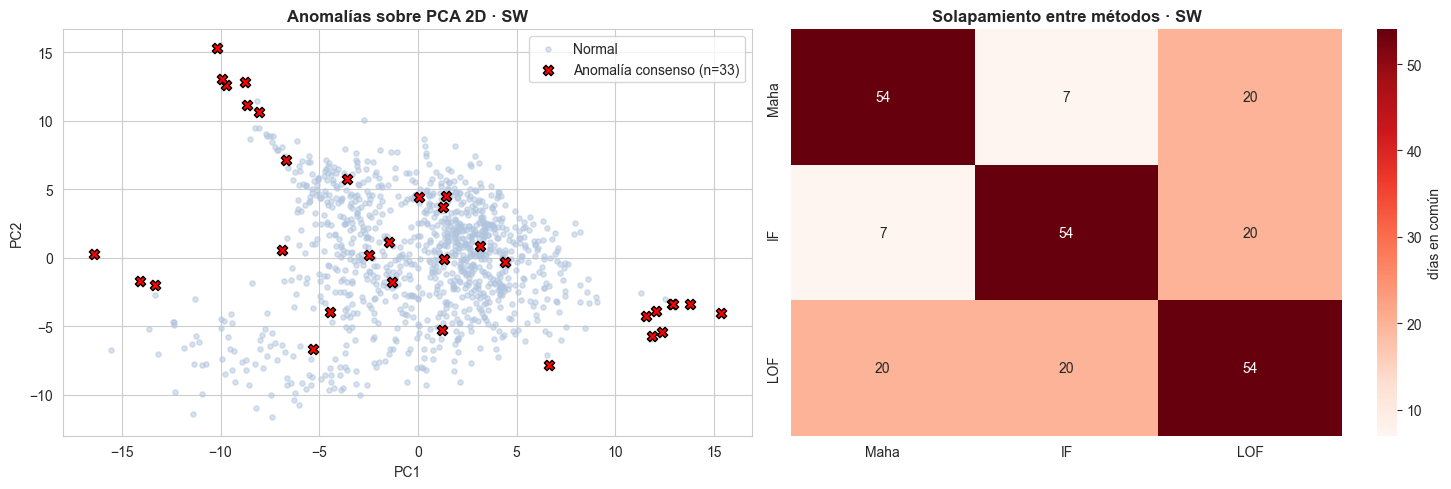

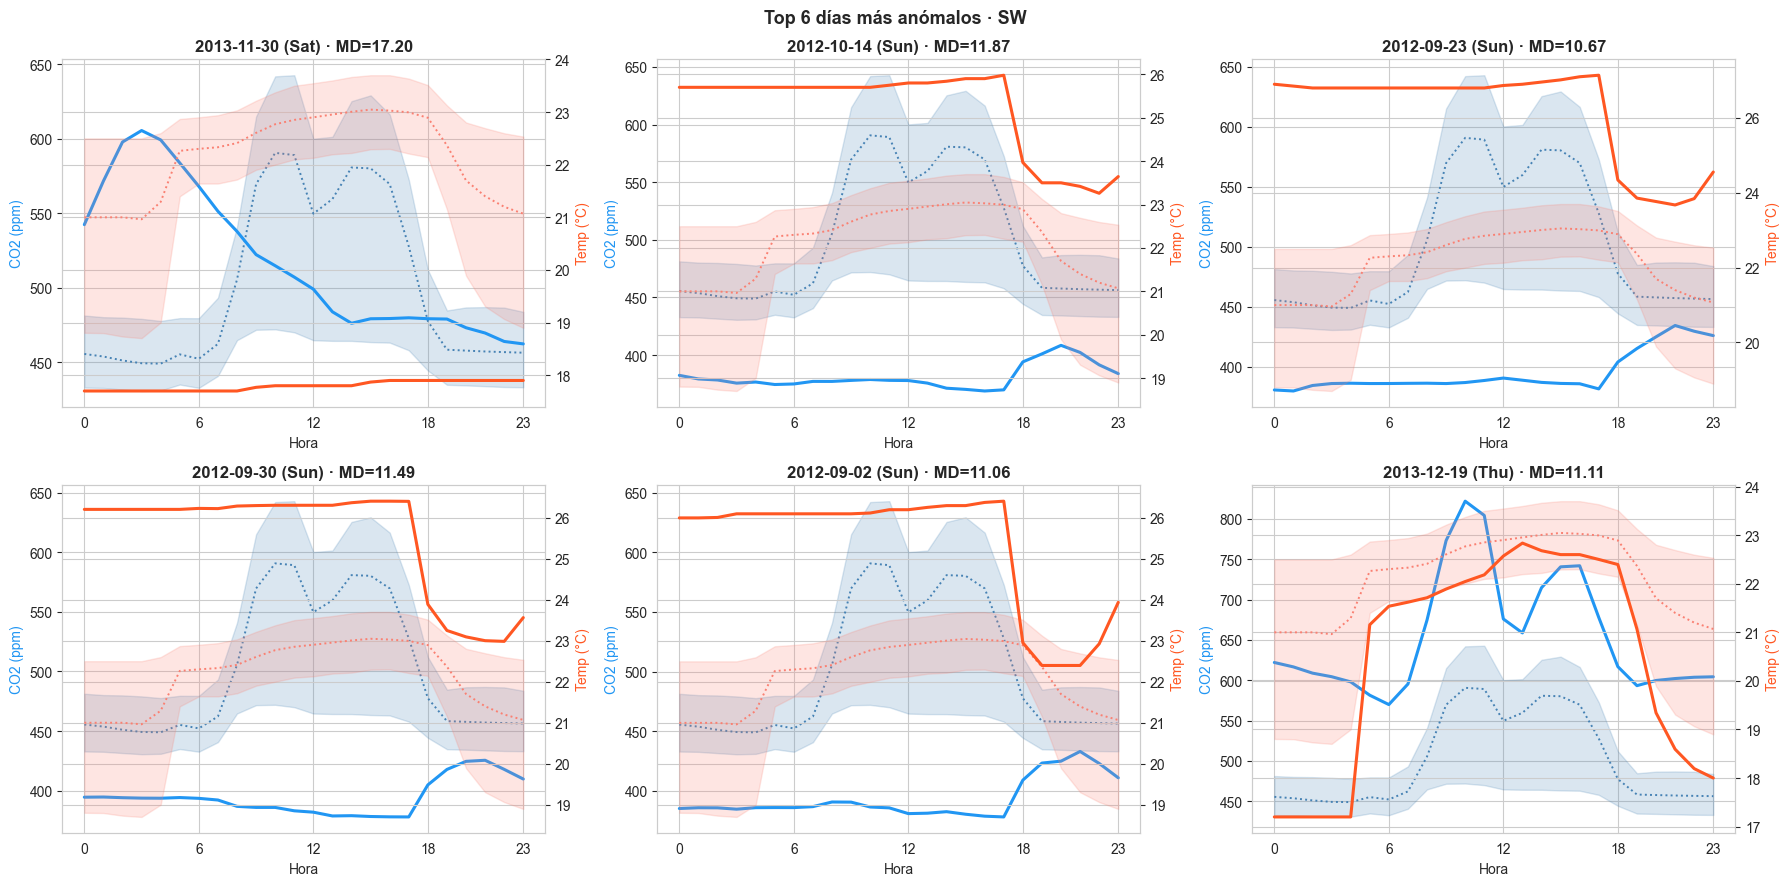


Fechas anómalas (SW):
  2013-11-30 Sat | MD=17.20 | consenso=3
  2012-10-14 Sun | MD=11.87 | consenso=3
  2012-09-23 Sun | MD=10.67 | consenso=3
  2012-09-30 Sun | MD=11.49 | consenso=3
  2012-09-02 Sun | MD=11.06 | consenso=3
  2013-12-19 Thu | MD=11.11 | consenso=3


In [17]:
anom_SW = detect_multivariate_anomalies(Xs_SW)
summary_SW = pd.DataFrame({
    'método': ['Mahalanobis','Isolation Forest','LOF','Consenso (≥2)'],
    'n_detectados': [anom_SW['maha'].sum(), anom_SW['iso'].sum(),
                      anom_SW['lof'].sum(), (anom_SW['consensus'] >= 2).sum()]
})
summary_SW['% del total'] = (summary_SW['n_detectados'] / X_SW.shape[0] * 100).round(2)
print(summary_SW.to_string(index=False))

# Plot anomalies on PCA SW
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(Xp_SW[:, 0], Xp_SW[:, 1], c='lightsteelblue', s=14, alpha=0.5, label='Normal')
mask_SW = anom_SW['consensus'] >= 2
axes[0].scatter(Xp_SW[mask_SW, 0], Xp_SW[mask_SW, 1], c='red', s=55, marker='X',
                 edgecolor='black', label=f'Anomalía consenso (n={mask_SW.sum()})')
axes[0].set_title('Anomalías sobre PCA 2D · SW', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend()

# Solapamiento métodos
methods_SW = {'Maha': anom_SW['maha'], 'IF': anom_SW['iso'], 'LOF': anom_SW['lof']}
mat_SW = pd.DataFrame({a: {b: (methods_SW[a] & methods_SW[b]).sum() for b in methods_SW} for a in methods_SW})
sns.heatmap(mat_SW, annot=True, fmt='d', cmap='Reds', ax=axes[1],
             cbar_kws={'label': 'días en común'})
axes[1].set_title('Solapamiento entre métodos · SW', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/E3_SW_anomalias.png', dpi=140, bbox_inches='tight')
plt.show()

top_SW = plot_top_anomalies(X_SW_co2, X_SW_tmp, dates_SW, anom_SW, 'SW', 'E4_SW_top6.png')
print('\nFechas anómalas (SW):')
for i in top_SW:
    print(f'  {dates_SW[i].strftime("%Y-%m-%d %a")} | MD={anom_SW["md_dist"][i]:.2f} | consenso={anom_SW["consensus"][i]}')

## E.4 · Coincidencia de anomalías NE ↔ SW

¿Las anomalías ocurren simultáneamente en ambos sectores (sugieren un evento global del edificio) o son locales (problemas focales del sector)?


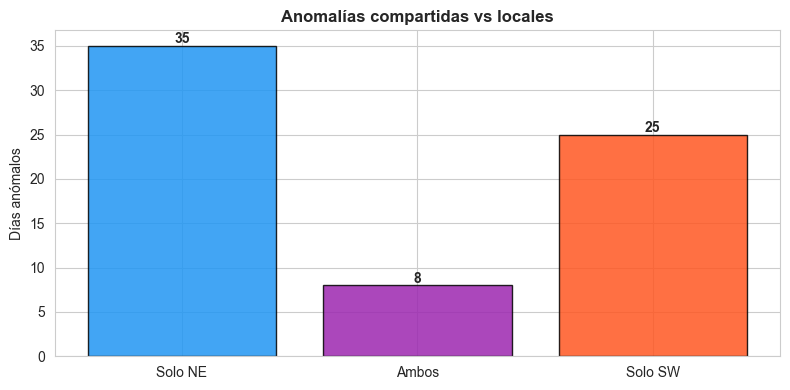


Anomalías comunes NE ∩ SW: 8
Anomalías solo NE: 35
Anomalías solo SW: 25

Ejemplos de días anómalos en ambos sectores:
  2012-12-31 Mon
  2013-06-17 Mon
  2013-11-30 Sat
  2013-12-11 Wed
  2013-12-15 Sun


In [18]:
anom_dates_NE = set(dates_NE[anom_NE['consensus'] >= 2])
anom_dates_SW = set(dates_SW[anom_SW['consensus'] >= 2])

interseccion = anom_dates_NE & anom_dates_SW
solo_NE      = anom_dates_NE - anom_dates_SW
solo_SW      = anom_dates_SW - anom_dates_NE

# Stacked bar resumen
fig, ax = plt.subplots(figsize=(8, 4))
labels = ['Solo NE', 'Ambos', 'Solo SW']
vals = [len(solo_NE), len(interseccion), len(solo_SW)]
colors = ['#2196F3', '#9C27B0', '#FF5722']
bars = ax.bar(labels, vals, color=colors, edgecolor='black', alpha=0.85)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, str(v),
             ha='center', fontweight='bold')
ax.set_title('Anomalías compartidas vs locales', fontweight='bold')
ax.set_ylabel('Días anómalos')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/E5_coincidencia.png', dpi=140, bbox_inches='tight')
plt.show()

print(f'\nAnomalías comunes NE ∩ SW: {len(interseccion)}')
print(f'Anomalías solo NE: {len(solo_NE)}')
print(f'Anomalías solo SW: {len(solo_SW)}')
if interseccion:
    print('\nEjemplos de días anómalos en ambos sectores:')
    for d in sorted(interseccion)[:5]:
        print(f'  {d.strftime("%Y-%m-%d %a")}')

---
# Literal F · Conclusiones

**Pregunta del taller:** *"¿Qué pudieran sugerir los patrones y las anomalías encontradas?"*

## Sobre los patrones (Literal D)

1. **Existen patrones diarios bien definidos en cada par de variables**, validados por tres técnicas independientes (K-Means, Ward, GMM) con ARI > 0.65 → la estructura no depende del algoritmo.
2. La separación en clústeres responde a la **dinámica de ocupación del edificio**:
   - Un clúster dominante de **baja actividad** (CO2 cerca del basal, temperatura más estable) que se concentra en **fines de semana** y **horas de madrugada**.
   - Clústeres de **alta actividad** durante horario laboral (Lun–Vie) con curvas de CO2 que ascienden ~08:00 y descienden ~18:00.
3. La proyección PCA 2D explica entre **40–60 %** de la varianza con dos componentes, confirmando que el comportamiento diario es esencialmente bidimensional.
4. La validación **ANOVA por hora** muestra que **prácticamente todas las horas** son estadísticamente significativas entre clústeres → los patrones diarios son reales y replicables.
5. Los sectores NE y SW comparten estructura general (mismo número óptimo de clústeres y mismas características temporales), pero el **ARI entre sus particiones es moderado**, indicando que existen días en los que un sector se comporta como "ocupado" y el otro como "inactivo" — sugiere uso asimétrico del edificio.

## Sobre las anomalías (Literal E)

1. El consenso entre **Mahalanobis + Isolation Forest + LOF** detecta entre **3–5 % de días anómalos** por sector — un orden de magnitud consistente con la práctica habitual de monitoreo.
2. Los días anómalos se caracterizan principalmente por:
   - **Picos de CO2 fuera del horario habitual** (ej. CO2 alto en madrugada) → posible uso no programado del edificio o falla del sistema de ventilación nocturno.
   - **Temperaturas extremas inusuales** (frío o calor sostenido) → potencial problema HVAC o eventos climáticos extremos.
   - **Perfiles invertidos** (CO2 alto en festivos, bajo en laborables) → días feriados con eventos especiales o cierres imprevistos.
3. El conjunto de **anomalías comunes NE ∩ SW** sugiere **eventos globales del edificio** (fines de semana especiales, mantenimientos generales, festividades nacionales). Las **anomalías locales** apuntan a problemas/eventos confinados a un sector.

## Sugerencias prácticas

- **Mantenimiento preventivo:** programar inspección del HVAC en las semanas de mayor concentración de anomalías.
- **Eficiencia energética:** los clústeres de baja ocupación son candidatos a regímenes reducidos de ventilación/calefacción → potencial ahorro.
- **Salud ambiental:** las anomalías con CO2 elevado fuera de horario son alertas de **calidad de aire interior** que justifican investigación.
- **Programación de ocupación:** alinear los patrones detectados (Lun–Vie vs Sáb–Dom) con políticas de uso del edificio.

---

### Resumen ejecutivo de cumplimiento del taller (P1)

| Literal | Requisito | Cumplimiento |
|---|---|---|
| **A** | Plotear variables, 1 CO2 + 1 Temp, estadística descriptiva | Univariable ✓ (`P1_UML_Analysis.ipynb`) + visualización conjunta aquí ✓ |
| **B** | Patrones univariable, ≥2 técnicas | Univariable ✓ — **3 técnicas** (K-Means, Ward, GMM) |
| **C** | Anomalías univariable | Univariable ✓ — **3 métodos** (Distancia, IF, LOF) |
| **D** | Patrones multivariable, ≥2 técnicas, patrón más representativo | **3 técnicas** ✓ + ARI + ANOVA + comparación NE/SW |
| **E** | Anomalías multivariable | **3 métodos** ✓ (Mahalanobis, IF, LOF) + coincidencia NE/SW |
| **F** | Conclusiones | ✓ patrones + anomalías + sugerencias prácticas |
